In [79]:
import matplotlib.pyplot as plt
import pandas as pd

=============================
LOAD AND PREPARE DATA
=============================

In [80]:
def load_data(filename):
    """
    Loads the Spotify CSV and returns a cleaned DataFrame.
    """
    df = pd.read_csv(filename)

    df["primary_genre"] = df["genre"].str.split(",").str[0].str.strip()

    df["decade"] = (df["year"] // 10) * 10

    return df

In [81]:
def display_audio_features_by_genre(df: pd.DataFrame):
    # Step 1: Find the most common genres (10 of them)
    top_genres = df["primary_genre"].value_counts().head(10).index

    # Step 2: Filter the dateframe to only those selected genres
    df_top = df[df["primary_genre"].isin(top_genres)]

    genre_means = df_top.groupby("primary_genre")[["danceability", "energy", "valence"]].mean()

    fig, ax = plt.subplots(figsize=(12,6))

    genre_means.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c", "#2ecc71"])

    ax.set_title("Average Audio Features by Genre", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Genre")
    ax.set_ylabel("Average Score")
    ax.legend(title="Features", fontsize=10, loc="upper right")

    ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()

    plt.savefig("spotify_visualization.png")

    plt.show()

In [82]:
def popularity_by_explicit(df):
    """
    Plots two overalapping histograms of song popularity:
        - one for explicit songs (explicit = True)
        - one for non-explicit songs (explicit = False)

    Overlapping the two on the same axes makes it easy to compare their distributions side by side.
    """
    # Step 1: Split the data into two groups
    non_explicit = df[df["explicit"] == False]["popularity"]
    explicit = df[df["explicit"] == True]["popularity"]

    # Step 2: Split the data into two groups
    fig, ax = plt.subplots(figsize=(12,6))

    # alpha controls transparency (0 = invisible, 1 = solid)
    # bins=20 divides the popularity range(0-100) into 20 equal bins/buckets/groups
    ax.hist(non_explicit, bins=20, color="#3498db", label="Not Explicit", alpha=0.8, edgecolor="white")

    ax.hist(explicit, bins=20, color="#e74c3c", label="Explicit", alpha=0.8, edgecolor="white")

    # Step 3 - Add labels and formatting
    ax.set_title("Song Popularity: Explicit vs Non-Explicit", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Popularity", fontsize=12)
    ax.set_ylabel("Number of Songs", fontsize=12)
    ax.legend(title="Song Type", fontsize=10)

    plt.tight_layout()
    plt.savefig("popularity_explicit.png", dpi=300, bbox_inches="tight")
    plt.show()

In [83]:
def energy_vs_danceability(df):
    """
    Creates a scatter plot of energy (x-axis) vs danceability (y-axis).
    Each dot in one song, and the color of the dot tells the decade the song is from.

    This lets us sport patterns like: "did songs get more energetic over time?" or "is there a relationship between energy and danceability?"
    """
    # Step 1: Define a color for each decade
    decade_colors = {
        1990: "#9e11ad", #purple
        2000: "#e74c3c", #red
        2010: "#042BBF", #blue
        2020: "#15e85f", #green
    }

    # Step 2: Draw the scatter plot
    fig, ax = plt.subplots(figsize=(10, 7))

    for decade, group in df.groupby("decade"):
        color = decade_colors.get(decade, "#95a5a6")
        ax.scatter(
            df["energy"], df["danceability"], color=color,
             s=16, label=f"{decade}s",
        )

    ax.set_xlabel("Energy")
    ax.set_ylabel("Danceability")
    ax.set_title("Energy vs Danceability by Decade", fontsize=16, fontweight="bold", pad=15)
    ax.legend(title="Decade", fontsize=10, markerscale=2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

4. Create a figure with 2 subplots side by side:
Left: Distribution of tempo for hip hop songs
Right: Distribution of tempo for pop songs

In [84]:
def tempo_hiphop_vs_pop(df):
    hiphop_df = df[df["primary_genre"] == "hip hop"]["tempo"].dropna()
    pop_df = df[df["primary_genre"] == "pop"]["tempo"].dropna()

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    ax[0].hist(hiphop_df, bins=25, color="#e74c3c", edgecolor="white", alpha=0.9)

    ax[0].set_title("Hip Hop: Tempo Distribution", fontsize=14, fontweight="bold", pad=15)


    ax[1].hist(pop_df, bins=25, color="#3498db", edgecolor="white", alpha=0.9)

    ax[1].set_title("Pop: Tempo Distribution", fontsize=14, fontweight="bold", pad=15)

    plt.show()

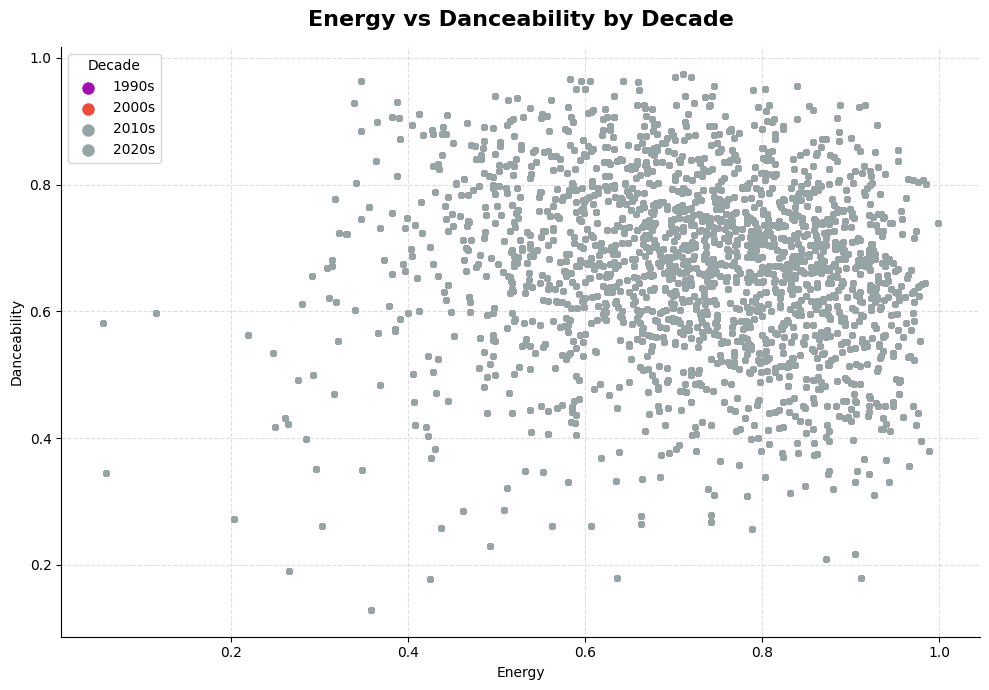

In [85]:
spotify_df = load_data("../../data/spotify_top_hits_2000_2009.csv")

# display_audio_features_by_genre(spotify_df)
energy_vs_danceability(spotify_df)
# tempo_hiphop_vs_pop(spotify_df)